# Objectif du notebook 

Date de création : 17/12/2025

L'objectif de ce notebook est de mettre en forme une partie des données utilisées dans la suite de l'analyse :

* Données AIS 
* Données GPS 
* Données SBE OBS 
* Fond de carte bathy pour les représentations 

Les données sont chargées et mise en forme puis sauvegardées au format netcdf sous la forme de dataset xarray afin de faciliter la manipulation et la représentation des données. 

Un travail préliminaire est fait afin de projeter l'ensemble des positions (AIS/GPS) dans un repère local ENU dont l'origine est définie par la position a priori de l'OBS 2. 

In [1]:
import os
import sys
import datetime
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_metadata = os.path.join(root_groix_data, "metadata")
root_groix_ais = os.path.join(root_groix_data, "ais")
if not os.path.exists(root_groix_ais):
    os.makedirs(root_groix_ais)
root_groix_gps = os.path.join(root_groix_data, "gps")
if not os.path.exists(root_groix_gps):
    os.makedirs(root_groix_gps)
root_bathy_data = os.path.join(project_root, "data", "bathy")

ais_spationav_fpath = os.path.join(root_groix_ais, "SPATIONAV_AIS_001.csv")
root_gps_not_parsed = r"C:\Users\baptiste.menetrier\Desktop\ressource\XP_Fiberscope_Groix_092025\Jules\gps"

# Current folder
root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [3]:
sys.path.append(project_root)

from real_data_analysis.fiberscope_groix.src.data_prepocessing.preprocess_utils import (
    build_SBE_dataset,
    plot_SBE,
    load_apriori_pos_wgs84,
    set_apriori_pos_h,
    load_bathy,
    plot_bathy,
    get_obs_immersion,
    build_AIS_dataset,
    build_GPS_dataset,
    build_BATHY_dataset,
)
from misc import progression_bar
from source.utils.utils_gps import gpx_to_csv, interpolate_gps
from source.utils.utils_geo import geodetic_to_ecef, ecef_to_enu
from publication.publication_figure import PubFigure, color

# Chargement des données et mise en forme 

## Données SBE des OBS 

In [4]:
sbe_data_folder = os.path.join(root_groix_data, "SBE39_OBS")
interpolation_time_step = "30s"
ds_SBE = build_SBE_dataset(
    sbe_data_folder=sbe_data_folder, interpolation_time_step=interpolation_time_step
)

*END*

*END*

*END*



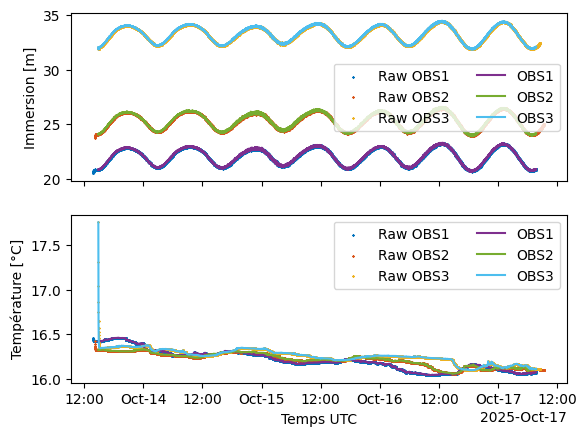

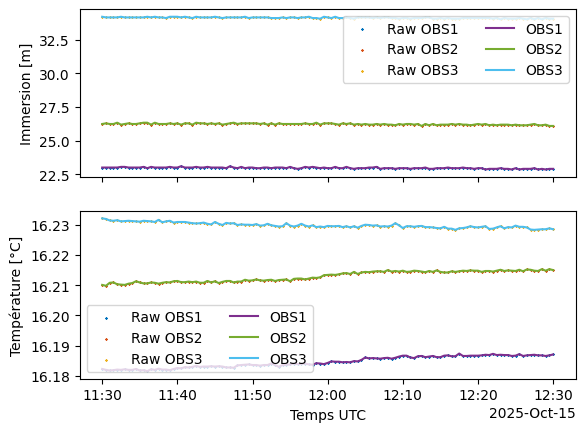

In [5]:
plot_SBE(ds_SBE=ds_SBE)

## Positions a priori des OBS

In [6]:
N_geoid_undulation = 49.6795
apriori_pos_wgs84_before_campaign, apriori_pos_wgs84 = load_apriori_pos_wgs84(
    root_groix_metadata=root_groix_metadata
)
set_apriori_pos_h(
    apriori_pos_wgs84=apriori_pos_wgs84,
    N_geoid_undulation=N_geoid_undulation,
    ds_SBE=ds_SBE,
    verbose=False,
)
set_apriori_pos_h(
    apriori_pos_wgs84=apriori_pos_wgs84_before_campaign,
    N_geoid_undulation=N_geoid_undulation,
    ds_SBE=ds_SBE,
    verbose=False,
)

In [7]:
apriori_pos_wgs84

,lat,lon,h
id,,,
obs1,47.662280,-3.472260,27.646929
obs2,47.669110,-3.465840,24.384320
obs3,47.676760,-3.460270,16.463733
t1,47.661667,-3.467500,49.679500
t2,47.661667,-3.456667,49.679500
t3,47.661667,-3.445833,49.679500
t4,47.661667,-3.433333,49.679500
t5,47.661667,-3.420833,49.679500


In [8]:
# Coordonnées de le l'origine du repère de référence
obs_pos_id = "obs2"
pos0 = apriori_pos_wgs84.loc[obs_pos_id]
lat0 = np.radians(pos0.lat)
lon0 = np.radians(pos0.lon)
h0 = pos0.h

local_frame_origin = {
    "id": obs_pos_id,
    "lat": lat0,
    "lon": lon0,
    "h": h0,
}

In [9]:
local_frame_origin

{'id': 'obs2',
 'lat': 0.8319829209953542,
 'lon': -0.06049031934732027,
 'h': 24.384320262664165}

## Données bathy pour le fond de carte 

La zone sélectionnée est une zone de 0.25° x 0.25° soit environ 37.56 km x 55.6 km 

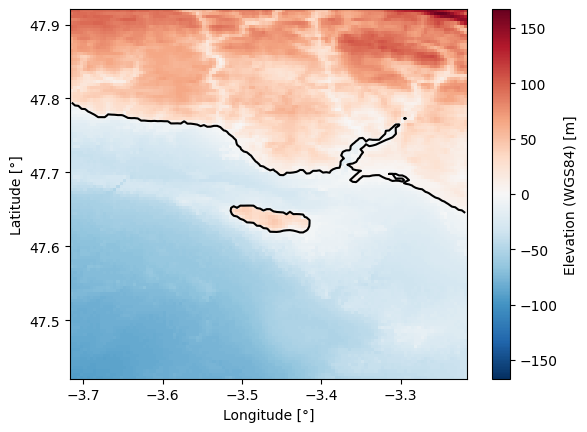

In [10]:
ds_bathy = build_BATHY_dataset(local_frame_origin, root_bathy_data=root_bathy_data)
plot_bathy(ds_bathy, contour_levels=[0])

## Interpolation des données GPS et des données AIS sur une base de temps régulière 

La période d'échantillonnage des données GPS et des données AIS n'est pas constante. Pour simplifier la suite du traitement on interpole la trajectoire du navire avec un pas de temps fixe de 10 secondes. La trajectoire est supposée rectiligne entre deux positions successives. 

In [11]:
time_step = "10s"  # 10 seconds
t_start = pd.Timestamp("2025-10-13 08:00:00", tz="UTC")
t_end = pd.Timestamp("2025-10-17 09:47:50", tz="UTC")

In [12]:
ds_ais = build_AIS_dataset(
    local_frame_origin=local_frame_origin,
    N_geoid_undulation=N_geoid_undulation,
    t_start=t_start,
    t_end=t_end,
    ds_SBE=ds_SBE,
    interpolation_time_step=time_step,
    ais_spationav_fpath=ais_spationav_fpath,
    root_groix_metadata=root_groix_metadata,
)

ds_gps = build_GPS_dataset(
    local_frame_origin=local_frame_origin,
    N_geoid_undulation=N_geoid_undulation,
    t_start=t_start,
    t_end=t_end,
    ds_SBE=ds_SBE,
    interpolation_time_step=time_step,
    root_groix_gps=root_groix_gps,
    root_groix_metadata=root_groix_metadata,
)

In [14]:
# Save datasets to netcdf files
ds_gps.to_netcdf(os.path.join(data_folder, "gps.nc"))
ds_ais.to_netcdf(os.path.join(data_folder, "ais.nc"))
ds_bathy.to_netcdf(os.path.join(data_folder, "bathy.nc"))
ds_SBE.to_netcdf(os.path.join(data_folder, "sbe39_obs.nc"))